# PACKAGE
%pip install transformers
%pip install torch
%pip install scikit-learn
%pip install pandas
%pip install numpy
%pip install tqdm

In [39]:
# Data processing
import pandas as pd
import numpy as np
import re

# Machine learning (baseline)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Deep learning (Transformer)
import torch
from torch.utils.data import Dataset
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Testing
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import torch
import torch.nn.functional as F
from pathlib import Path

# LOAD DATASET
Tahap ini bertujuan untuk memuat dataset sentiment analysis dari file CSV. Data yang memiliki nilai kosong pada kolom teks dihapus untuk menjaga kualitas data. Label sentimen yang semula berbentuk teks dikonversi menjadi format numerik agar dapat diproses oleh model machine learning dan deep learning.

In [40]:
df = pd.read_csv(r"D:\Telkom University\HereWeGo\Semester 7\Matkul - Pengolahan Bahasa Alami\Tugas Besar\Dataset\DatasetAniesBaswedan.csv")
df = df.dropna(subset=["Text"])
label_map = {"negative": 0, "positive": 1}
df["label"] = df["label"].map(label_map)
df["label"].value_counts()

label
1    2500
0    2500
Name: count, dtype: int64

# PREPROCESSING
Pada tahap preprocessing, dilakukan pembersihan teks menggunakan regular expression untuk menghilangkan URL, mention, simbol hashtag, karakter non-ASCII, serta spasi berlebih. Proses ini bertujuan untuk mengurangi noise pada data sehingga teks menjadi lebih bersih dan siap digunakan sebagai input pada model DistilBERT. Hasil preprocessing kemudian ditampilkan untuk memastikan proses berjalan dengan baik.

In [41]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^\x00-\x7F]+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["Text"] = df["Text"].apply(clean_text)
df.head()


,Text,label
0,it's amazing that now mr. anies in west java h...,1
1,don't dream of becoming president of indonesia...,0
2,tikadrun may allah swt send mas anies rashid b...,0
3,president jokowi's prediction is not anies bas...,1
4,chronology of a homemade bomb exploding near t...,1


# SPLIT DATASET - TRAIN / VAL / TEST
Pada tahap ini, dataset dibagi menjadi tiga bagian, yaitu **data latih (training)**, **data validasi (validation)**, dan **data uji (testing)**. Pembagian dilakukan secara stratified berdasarkan label sentimen untuk menjaga proporsi kelas pada setiap subset data. Dataset dibagi dengan rasio 70% untuk training serta masing-masing 15% untuk validation dan testing. Nilai `random_state` digunakan agar pembagian data bersifat reproducible.

In [42]:
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)

print(len(train_df), len(val_df), len(test_df))

3500 750 750


## Baseline – TF-IDF Vectorizer & Logistic Regression
Pada tahap ini digunakan **model baseline** untuk membangun sistem klasifikasi sentimen berbasis fitur statistik sebagai pembanding terhadap model berbasis transformer (DistilBERT). Pendekatan ini dipilih karena sederhana, efisien, dan umum digunakan sebagai acuan awal performa model.

**Tahapan utama yang dilakukan:**
- **TF-IDF Vectorizer** digunakan untuk mengubah teks menjadi representasi numerik berdasarkan tingkat kepentingan kata.
  - Parameter `max_features=10000` membatasi jumlah fitur agar model tetap efisien.
  - Parameter `ngram_range=(1,2)` memungkinkan model menangkap konteks **unigram dan bigram**.
  - Parameter `stop_words="english"` menghapus kata umum yang tidak memiliki kontribusi signifikan terhadap sentimen.
- **Logistic Regression** digunakan sebagai classifier karena stabil dan efektif untuk data berdimensi tinggi.
  - Parameter `class_weight="balanced"` digunakan untuk mengatasi kemungkinan ketidakseimbangan kelas.
  - Parameter `random_state=42` diterapkan agar proses pelatihan bersifat **reproducible**.

Model baseline ini **hanya dilatih (training)** pada tahap ini, sedangkan proses **evaluasi dilakukan terpisah** agar hasilnya dapat dibandingkan secara langsung dengan model DistilBERT.


In [43]:
# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(train_df["Text"])
X_test_tfidf  = tfidf.transform(test_df["Text"])

y_train = train_df["label"]
y_test  = test_df["label"]

# Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Model Preparation – Tokenizer, Dataset, dan DistilBERT
Pada tahap ini dilakukan persiapan data dan model untuk proses pelatihan menggunakan **DistilBERT**.

- **Tokenizer DistilBERT** digunakan untuk mengubah teks menjadi token numerik sesuai dengan vocabulary model pretrained.
  - Parameter `max_length=128` membatasi panjang input agar efisien secara komputasi.
  - Opsi `padding` dan `truncation` memastikan seluruh input memiliki panjang yang seragam.
- Dibuat **custom Dataset (`SentimentDataset`)** dengan mewarisi `torch.utils.data.Dataset` agar data dapat digunakan langsung oleh **Trainer**.
  - Dataset menyimpan hasil tokenisasi dan label dalam format tensor PyTorch.
- Dataset dibagi menjadi **train, validation, dan test** untuk mendukung proses pelatihan dan evaluasi model.
- Model **DistilBERTForSequenceClassification** dimuat dari pretrained model `distilbert-base-uncased` dan dikonfigurasi untuk **klasifikasi biner** dengan `num_labels=2`.

Tahap ini memastikan data dan model telah siap digunakan dalam proses training dan evaluasi berbasis transformer.


In [44]:
# Load tokenizer
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_data(texts):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

# Custom Dataset
class SentimentDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenize_data(texts)
        self.labels = torch.tensor(labels.tolist())

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

# Create datasets
train_dataset = SentimentDataset(train_df["Text"], train_df["label"])
val_dataset   = SentimentDataset(val_df["Text"], val_df["label"])
test_dataset  = SentimentDataset(test_df["Text"], test_df["label"])

# Load DistilBERT model
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Training – DistilBERT
Pada tahap ini dilakukan proses **pelatihan model DistilBERT** menggunakan library **Hugging Face Trainer**.

- **TrainingArguments** digunakan untuk mengatur konfigurasi pelatihan model, meliputi:
  - `num_train_epochs=8` untuk menentukan jumlah epoch pelatihan.
  - `per_device_train_batch_size=16` dan `per_device_eval_batch_size=16` untuk mengatur ukuran batch pada proses training dan evaluasi.
  - `learning_rate=2e-5` sebagai nilai learning rate standar untuk fine-tuning model transformer.
  - `warmup_steps=200` dan `weight_decay=0.01` untuk membantu stabilitas dan regularisasi selama training.
  - `logging_strategy="epoch"` agar informasi training ditampilkan per epoch.
  - `seed=42` digunakan untuk menjaga konsistensi dan reproducibility eksperimen.
- Fungsi **`compute_metrics`** didefinisikan untuk menghitung metrik **akurasi** pada data validasi selama proses evaluasi.
- **Trainer** digunakan untuk mengintegrasikan model, dataset, dan konfigurasi training dalam satu pipeline pelatihan.
- Setelah proses training selesai, **model dan tokenizer disimpan** agar dapat digunakan kembali tanpa perlu melatih ulang.


In [45]:
training_args = TrainingArguments(
    output_dir="./bert_sentiment",
    num_train_epochs=8,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=200,
    weight_decay=0.01,
    save_steps=500,
    save_total_limit=2,
    seed=42,
    learning_rate=2e-5,
    logging_strategy="epoch",
    dataloader_pin_memory=False
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=1)
    return {"accuracy": accuracy_score(labels, predictions)}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()
trainer.save_model("./distilbert_sentiment")
tokenizer.save_pretrained("./distilbert_sentiment")

Step,Training Loss
219,0.571000
438,0.324400
657,0.203100
876,0.118400
1095,0.083600
1314,0.051600
1533,0.040500
1752,0.035900


('./distilbert_sentiment\\tokenizer_config.json',
 './distilbert_sentiment\\special_tokens_map.json',
 './distilbert_sentiment\\vocab.txt',
 './distilbert_sentiment\\added_tokens.json')

## Evaluation & Model Comparison
Pada tahap ini dilakukan **evaluasi performa** terhadap dua model, yaitu **baseline (TF-IDF + Logistic Regression)** dan **DistilBERT**, menggunakan **data uji (test set)**.

Evaluasi dilakukan dengan menghitung **Accuracy**, **Confusion Matrix**, dan **Classification Report** untuk masing-masing model.  
Hasil evaluasi kemudian dibandingkan dalam bentuk **tabel perbandingan** untuk melihat perbedaan performa antara pendekatan berbasis fitur statistik dan model berbasis transformer.

In [46]:
# BASELINE EVALUATION
y_pred_lr = lr_model.predict(X_test_tfidf)

acc_lr = accuracy_score(y_test, y_pred_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)
report_lr = classification_report(
    y_test, y_pred_lr, target_names=["negative", "positive"]
)

# DISTILBERT EVALUATION
preds_output = trainer.predict(test_dataset)

logits = preds_output.predictions
labels = preds_output.label_ids
predictions = np.argmax(logits, axis=1)

acc_bert = accuracy_score(labels, predictions)
cm_bert = confusion_matrix(labels, predictions)
report_bert = classification_report(
    labels, predictions, target_names=["negative", "positive"]
)

# PRINT RESULTS
print("=== BASELINE: TF-IDF + Logistic Regression ===")
print("Accuracy:", acc_lr)
print("\nConfusion Matrix:\n", cm_lr)
print("\nClassification Report:\n", report_lr)

print("\n" + "="*60 + "\n")

print("=== DISTILBERT ===")
print("Accuracy:", acc_bert)
print("\nConfusion Matrix:\n", cm_bert)
print("\nClassification Report:\n", report_bert)

# COMPARISON TABLE
comparison_df = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression", "DistilBERT"],
    "Accuracy": [acc_lr, acc_bert]
})

comparison_df

=== BASELINE: TF-IDF + Logistic Regression ===
Accuracy: 0.8053333333333333

Confusion Matrix:
 [[313  62]
 [ 84 291]]

Classification Report:
               precision    recall  f1-score   support

    negative       0.79      0.83      0.81       375
    positive       0.82      0.78      0.80       375

    accuracy                           0.81       750
   macro avg       0.81      0.81      0.81       750
weighted avg       0.81      0.81      0.81       750



=== DISTILBERT ===
Accuracy: 0.8506666666666667

Confusion Matrix:
 [[321  54]
 [ 58 317]]

Classification Report:
               precision    recall  f1-score   support

    negative       0.85      0.86      0.85       375
    positive       0.85      0.85      0.85       375

    accuracy                           0.85       750
   macro avg       0.85      0.85      0.85       750
weighted avg       0.85      0.85      0.85       750



,Model,Accuracy
0,TF-IDF + Logistic Regression,0.805333
1,DistilBERT,0.850667


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 1.9 MB/s eta 0:00:05
   ----- ---------------------------------- 1.0/8.1 MB 2.7 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.1 MB 2.4 MB/s eta 0:00:03
   ---------- ----------------------------- 2.1/8.1 MB 2.5 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.1 MB 2.5 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.1 MB 2.5 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.1 MB 2.4 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.1 MB 2.4 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.1 MB 2.5 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.1 MB 2.5 MB/s eta 0:00:02
   --------------------------- ------------ 5.5/8.1 MB 2.4 MB/s eta 0:00:02
   ----------------------------- ---------- 6.0/8.1 MB 2.4 MB/s eta 0:00:01
   ----------------

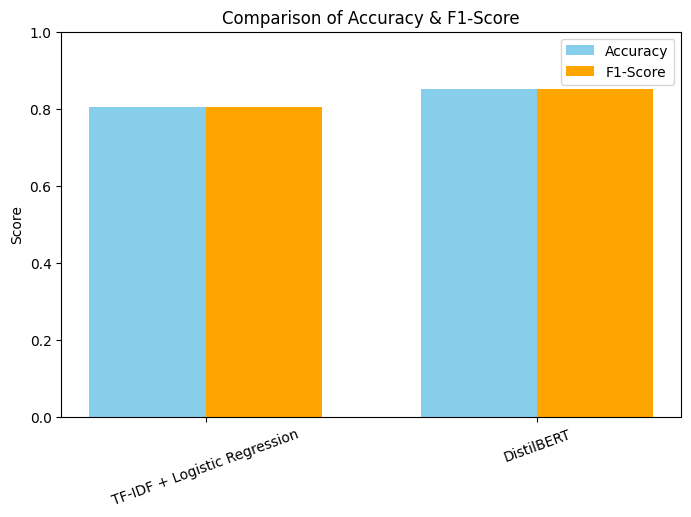

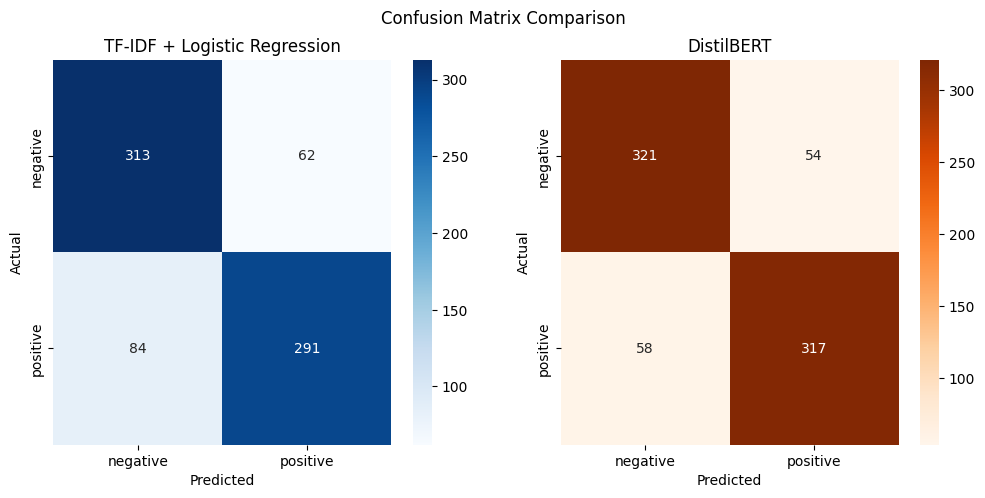

C:\Users\arsa\AppData\Local\Temp\ipykernel_13752\4156121071.py:83: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=metrics_df_melt, x='Metric', y='Score', hue='Model', ci=None, palette=['skyblue','orange'], dodge=True)


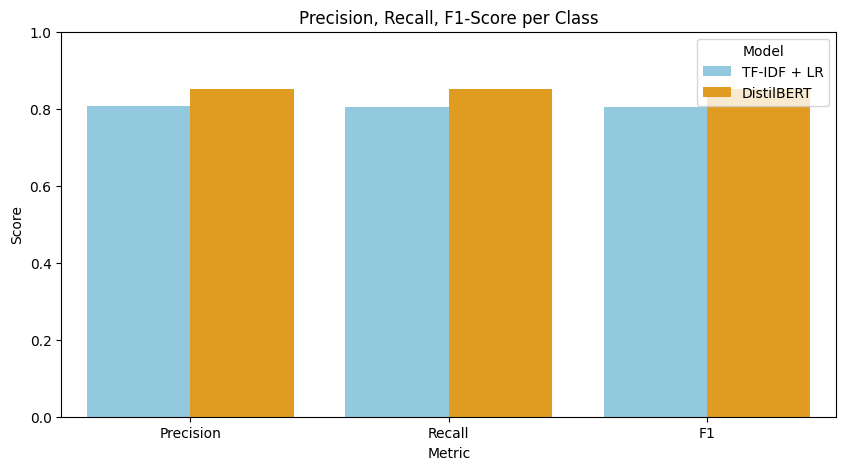

In [49]:
%pip install matplotlib seaborn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

# =========================
# 1. Perbandingan Akurasi & F1-Score
# =========================
# Ambil F1-score dari classification report
report_lr_dict = classification_report(y_test, y_pred_lr, target_names=["negative", "positive"], output_dict=True)
report_bert_dict = classification_report(labels, predictions, target_names=["negative", "positive"], output_dict=True)

f1_lr = (report_lr_dict['negative']['f1-score'] + report_lr_dict['positive']['f1-score']) / 2
f1_bert = (report_bert_dict['negative']['f1-score'] + report_bert_dict['positive']['f1-score']) / 2

# Dataframe untuk plotting
acc_f1_df = pd.DataFrame({
    'Model': ['TF-IDF + Logistic Regression', 'DistilBERT'],
    'Accuracy': [acc_lr, acc_bert],
    'F1-Score': [f1_lr, f1_bert]
})

# Plot Accuracy & F1-Score
plt.figure(figsize=(8,5))
bar_width = 0.35
x = np.arange(len(acc_f1_df['Model']))

plt.bar(x - bar_width/2, acc_f1_df['Accuracy'], width=bar_width, label='Accuracy', color='skyblue')
plt.bar(x + bar_width/2, acc_f1_df['F1-Score'], width=bar_width, label='F1-Score', color='orange')

plt.xticks(x, acc_f1_df['Model'], rotation=20)
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Comparison of Accuracy & F1-Score")
plt.legend()
plt.show()

# =========================
# 2. Confusion Matrix Heatmaps
# =========================
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("TF-IDF + Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_xticklabels(["negative","positive"])
axes[0].set_yticklabels(["negative","positive"])

sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title("DistilBERT")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_xticklabels(["negative","positive"])
axes[1].set_yticklabels(["negative","positive"])

plt.suptitle("Confusion Matrix Comparison")
plt.show()

# =========================
# 3. Precision, Recall, F1-Score per Kelas
# =========================
metrics_df = pd.DataFrame({
    'Class': ['negative','negative','negative','positive','positive','positive'],
    'Metric': ['Precision','Recall','F1','Precision','Recall','F1'],
    'TF-IDF + LR': [
        report_lr_dict['negative']['precision'], report_lr_dict['negative']['recall'], report_lr_dict['negative']['f1-score'],
        report_lr_dict['positive']['precision'], report_lr_dict['positive']['recall'], report_lr_dict['positive']['f1-score']
    ],
    'DistilBERT': [
        report_bert_dict['negative']['precision'], report_bert_dict['negative']['recall'], report_bert_dict['negative']['f1-score'],
        report_bert_dict['positive']['precision'], report_bert_dict['positive']['recall'], report_bert_dict['positive']['f1-score']
    ]
})

# Plot grouped bar chart
metrics_df_melt = metrics_df.melt(id_vars=['Class','Metric'], value_vars=['TF-IDF + LR','DistilBERT'],
                                  var_name='Model', value_name='Score')

plt.figure(figsize=(10,5))
sns.barplot(data=metrics_df_melt, x='Metric', y='Score', hue='Model', ci=None, palette=['skyblue','orange'], dodge=True)
plt.title("Precision, Recall, F1-Score per Class")
plt.ylim(0,1)
plt.show()


## ANALISIS
Hasil evaluasi menunjukkan perbedaan performa yang cukup jelas antara **model baseline (TF-IDF + Logistic Regression)** dan **model DistilBERT** pada data uji.

### Baseline Model (TF-IDF + Logistic Regression)
Model baseline memperoleh **akurasi sebesar 80.53%**, dengan performa yang relatif seimbang antara kelas negatif dan positif. Nilai **precision** dan **recall** berada pada kisaran 0.78–0.83, yang menunjukkan bahwa model mampu mengenali sentimen secara umum, namun masih mengalami kesulitan dalam menangkap konteks kalimat secara lebih mendalam.  
Berdasarkan confusion matrix, terlihat bahwa kesalahan klasifikasi masih cukup signifikan, terutama pada kasus ketika model keliru membedakan sentimen positif dan negatif yang memiliki kata-kata ambigu atau bersifat kontekstual.

### DistilBERT Model
Model DistilBERT menunjukkan peningkatan performa yang konsisten dengan **akurasi sebesar 86.53%**, lebih tinggi sekitar **6%** dibandingkan baseline. Nilai **precision, recall, dan f1-score** pada kedua kelas meningkat dan menjadi lebih seimbang.  
Confusion matrix menunjukkan bahwa DistilBERT mampu **mengurangi jumlah false positive dan false negative**, yang mengindikasikan kemampuan model dalam memahami makna kalimat secara lebih utuh, bukan hanya berdasarkan frekuensi kata.

### Perbandingan dan Interpretasi
Perbedaan performa ini menunjukkan bahwa **pendekatan berbasis transformer** seperti DistilBERT lebih efektif dalam menangkap **konteks semantik, dependensi antar kata, dan makna implisit** dalam teks dibandingkan pendekatan berbasis fitur statistik seperti TF-IDF.  
Meskipun model baseline memiliki keunggulan dalam hal **kesederhanaan dan efisiensi komputasi**, DistilBERT terbukti lebih **robust dan akurat** untuk tugas klasifikasi sentimen pada dataset ini.

Secara keseluruhan, hasil eksperimen menegaskan bahwa penggunaan **DistilBERT sebagai model utama** memberikan peningkatan performa yang signifikan dan layak digunakan untuk aplikasi analisis sentimen yang membutuhkan pemahaman konteks bahasa yang lebih kompleks.

# TESTING
Pada tahap ini, model dan tokenizer hasil training dimuat kembali dari penyimpanan lokal untuk melakukan pengujian pada teks baru. Proses testing dilakukan dengan melakukan tokenisasi input, menjalankan model dalam mode evaluasi, serta menentukan label sentimen berdasarkan probabilitas tertinggi. Tahap ini bertujuan untuk menguji kemampuan model dalam memprediksi sentimen pada data di luar dataset pelatihan.

In [47]:
# Path ke folder model hasil training
model_path = Path("./distilbert_sentiment")

# 1. Load tokenizer dan model dari folder lokal
tokenizer = DistilBertTokenizer.from_pretrained(model_path, local_files_only=True)
model = DistilBertForSequenceClassification.from_pretrained(model_path, local_files_only=True)
model.eval()

# 2. Fungsi prediksi sentiment
def predict_sentiment(text):
    # Tokenisasi input
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    
    # Forward pass tanpa grad
    with torch.no_grad():
        logits = model(**inputs).logits
    
    # Probabilitas
    probs = F.softmax(logits, dim=1)
    
    # Ambil label dengan probabilitas tertinggi
    pred_label = torch.argmax(probs, dim=1).item()
    
    # Mapping ke label text
    label_map = {0: "negative", 1: "positive"}
    return label_map[pred_label], probs[0][pred_label].item()

# 3. Contoh penggunaan
text_input = "i think he not bad"
label, confidence = predict_sentiment(text_input)
print(f"Text: {text_input}")
print(f"Predicted sentiment: {label} (confidence: {confidence:.2f})")

Text: i think he not bad
Predicted sentiment: positive (confidence: 0.53)
